## LSTM (RNN)

**Objetivo:** desenvolver e avaliar um modelo LSTM (*Long Short-Term Memory*) para previsão da concentração de PM2.5 com horizonte de 24 horas. O modelo será estruturado para aprender padrões temporais a partir de sequências históricas da série de PM2.5 e de variáveis meteorológicas, permitindo comparar seu desempenho com os modelos SARIMAX, LightGBM e DART.


*******
**Experimentos para o LSTM**

A modelagem com LSTM exige a transformação dos dados tabulares em sequências temporais. Para isso, serão construídas janelas históricas de entrada contendo observações passadas de PM2.5 e variáveis meteorológicas, com o objetivo de prever a concentração futura de PM2.5 para as próximas 24 horas.

Serão avaliadas diferentes configurações de:

- Tamanho da janela temporal de entrada (*lookback*);
- Horizonte de previsão;
- Variáveis de entrada;
- Escalonamento dos dados;
- Número de camadas LSTM;
- Número de unidades por camada;
- Taxa de dropout;
- Tamanho do batch;
- Número de épocas;
- Critérios de parada antecipada (*Early Stopping*).

************

**Conjunto de dados:**

      - 100% dos dados entre 2016-2019
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

************


In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Normalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Sequential, Input, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import L2

import shap

shap.initjs();

I0000 00:00:1782435304.332746   12848 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782435308.313443   12848 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782435327.297734   12848 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 1. Carregamento dos dados

In [3]:
# abrindo base de dados para treinamento/teste/validação
#data = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
data = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_full_features_2016_2019_fill_mean.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [4]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Feature Engineering

In [5]:
data_lstm = data.copy()

In [6]:
# Foram avaliadas diferentes features sazonais (ciclos diários, semanais e mensal) com o objetivo de melhorar a reprodução do modelo.
def cyclical_time_features(df):
    """
    Adiciona termos ciclicos como features exógenas
    df -> data

    """

    df = df.copy()

    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)


    df["weekday_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)


    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

    return df

In [7]:
data_lstm = cyclical_time_features(data_lstm)

In [8]:
data_lstm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
time,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,1.000000
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,0.965926
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,0.866025
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,0.707107
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,0.500000


In [9]:
# a reprodução dos meses de inverno teve o pior desempenho no SARIMAX
data_lstm["is_winter"] = data_lstm.index.month.isin([6, 7, 8]).astype(int)
data_lstm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos,is_winter
time,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,1.000000,0
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,0.965926,0
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,0.866025,0
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,0.707107,0
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,0.500000,0


In [10]:
print(data_lstm.shape)
print(f"NaN total: {data_lstm.isna().sum().sum()}")

(30363, 12)
NaN total: 0


**Adicionando lags no target e nas variáveis de meteorológica para tentar melhorar os resultados**

In [11]:
def add_lstm_features(df):
    df = df.copy()

    # lags do target
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"pm25_lag{lag}"] = df["MP2.5"].shift(lag)

    # lags meteorológicos
    for var in ["wind_speed_10m", "relative_humidity_2m"]:
        for lag in [6, 12, 24]:
            df[f"{var}_lag{lag}"] = df[var].shift(lag)

    return df

data_lstm = add_lstm_features(data_lstm)

### 3. Separando conjunto de treino, validação e teste

In [12]:
# mesma separação usada nos modelos anteriores, a diferença é que agora estou separando com o X e y juntos para preparar as sequencias
TRAIN_END = "2018-01-01"
VAL_END   = "2019-01-01"

train = data_lstm[data_lstm.index <  TRAIN_END]
val   = data_lstm[(data_lstm.index >= TRAIN_END) & (data_lstm.index < VAL_END)]
test  = data_lstm[data_lstm.index >= VAL_END]


In [13]:
print(f"Treino : {train.shape} | {train.index.min()} → {train.index.max()}")
print(f"Val    : {val.shape}   | {val.index.min()}   → {val.index.max()}")
print(f"Teste  : {test.shape}  | {test.index.min()}  → {test.index.max()}")

Treino : (16104, 24) | 2016-03-01 00:00:00+00:00 → 2017-12-31 23:00:00+00:00
Val    : (8760, 24)   | 2018-01-01 00:00:00+00:00   → 2018-12-31 23:00:00+00:00
Teste  : (5499, 24)  | 2019-01-01 00:00:00+00:00  → 2019-08-18 02:00:00+00:00


In [14]:
train.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,wind_speed_10m_lag6,wind_speed_10m_lag12,wind_speed_10m_lag24,relative_humidity_2m_lag6,relative_humidity_2m_lag12,relative_humidity_2m_lag24
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


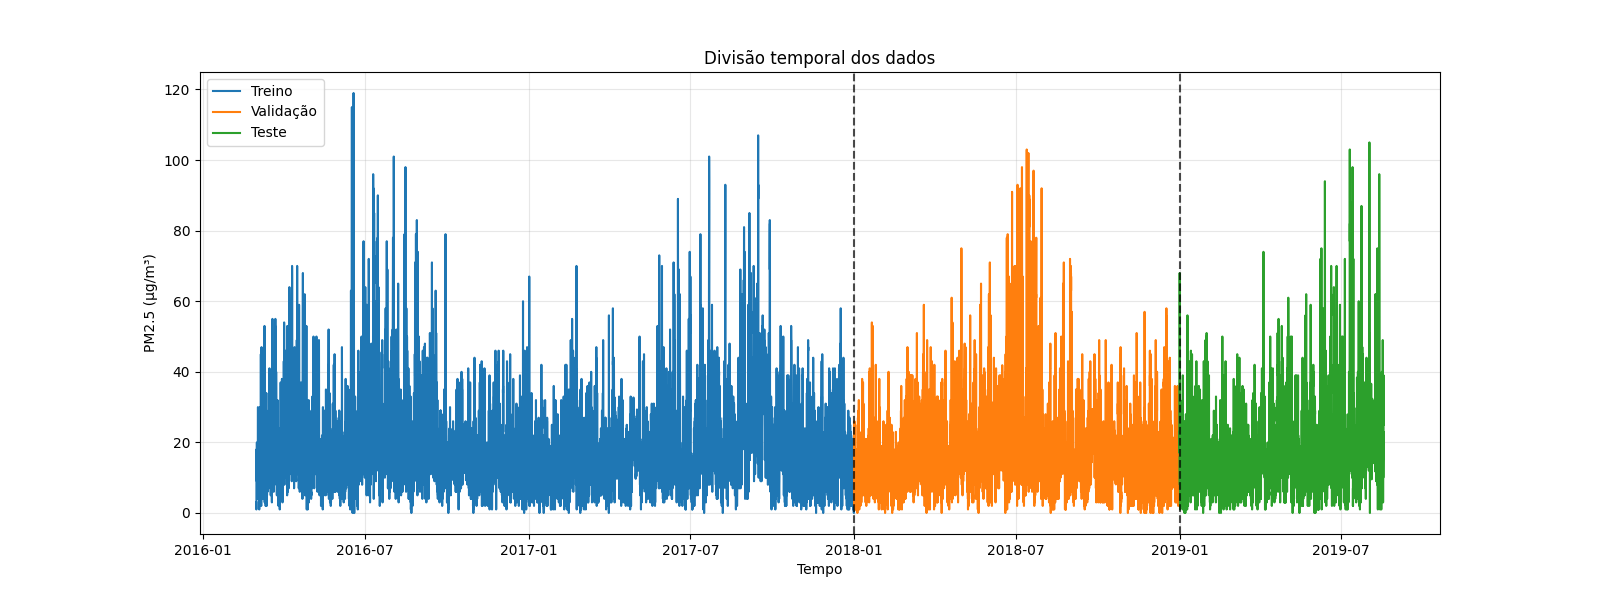

In [15]:
plt.figure(figsize=(16,6))

plt.plot(
    train['MP2.5'],
    label="Treino",
    color="tab:blue"
)

plt.plot(
    val['MP2.5'],
    label="Validação",
    color="tab:orange"
)

plt.plot(
    test['MP2.5'],
    label="Teste",
    color="tab:green"
)

plt.axvline(
    val['MP2.5'].index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    test['MP2.5'].index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.title("Divisão temporal dos dados")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Tempo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4. Padronização dos dados

In [16]:
TARGET = "MP2.5"

FEATURES = [
    "MP2.5",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos",
]

In [17]:
# filtrar apenas as features que o modelo vai usar
train_feat = train[FEATURES]
val_feat   = val[FEATURES]
test_feat  = test[FEATURES]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_feat)
val_scaled   = scaler.transform(val_feat)
test_scaled  = scaler.transform(test_feat)

target_idx = FEATURES.index(TARGET)


In [18]:
train_feat

,MP2.5,temperature_2m,relative_humidity_2m,wind_speed_10m,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos
time,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,12.538134,0.000000,1.000000,1.000000e+00,6.123234e-17,0.781831,0.62349
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,14.529915,0.258819,0.965926,1.000000e+00,6.123234e-17,0.781831,0.62349
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,12.538134,0.500000,0.866025,1.000000e+00,6.123234e-17,0.781831,0.62349
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,11.525623,0.707107,0.707107,1.000000e+00,6.123234e-17,0.781831,0.62349
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,12.979984,0.866025,0.500000,1.000000e+00,6.123234e-17,0.781831,0.62349
...,...,...,...,...,...,...,...,...,...,...
2017-12-31 19:00:00+00:00,8.0,24.150000,76.695366,21.677860,-0.965926,0.258819,-2.449294e-16,1.000000e+00,-0.781831,0.62349
2017-12-31 20:00:00+00:00,1.0,23.700000,79.042640,17.208603,-0.866025,0.500000,-2.449294e-16,1.000000e+00,-0.781831,0.62349
2017-12-31 21:00:00+00:00,1.0,23.300000,84.033005,16.870138,-0.707107,0.707107,-2.449294e-16,1.000000e+00,-0.781831,0.62349


### 5. Criando sequências

In [19]:
WINDOW   = 24   # wind_speed_lag24 e pm25_lag48 (SHAP)
HORIZON  = 24   # horizonte de previsão

In [20]:
def create_sequences(data_scaled, data_original, window, horizon, target_idx):

    Xs, ys = [], []
    x_indices, y_indices = [], []

    n = len(data_scaled)

    for i in range(n - window - horizon + 1):

        janela_completa = data_original.iloc[i : i + window + horizon]

        if janela_completa.isna().any().any():
            continue

        Xs.append(data_scaled[i : i + window])
        ys.append(data_scaled[i + window : i + window + horizon, target_idx])

        x_indices.append(data_original.index[i : i + window])
        y_indices.append(data_original.index[i + window : i + window + horizon])

    return np.array(Xs), np.array(ys), x_indices, y_indices

In [21]:
X_train, y_train, train_x_idx, train_y_idx = create_sequences(
    train_scaled, train_feat, WINDOW, HORIZON, target_idx
)

val_context = pd.concat([
    train_feat.iloc[-WINDOW:],
    val_feat
])

val_context_scaled = scaler.transform(val_context)

X_val, y_val, val_x_idx, val_y_idx = create_sequences(
    val_context_scaled, val_context, WINDOW, HORIZON, target_idx
)

test_context = pd.concat([
    val_feat.iloc[-WINDOW:],
    test_feat
])

test_context_scaled = scaler.transform(test_context)

X_test, y_test, test_x_idx, test_y_idx = create_sequences(
    test_context_scaled, test_context, WINDOW, HORIZON, target_idx
)

In [22]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Primeiro y_val:", val_y_idx[0][0], "até", val_y_idx[0][-1])
print("Primeiro y_test:", test_y_idx[0][0], "até", test_y_idx[0][-1])

X_train: (16057, 24, 10)
y_train: (16057, 24)
X_val: (8737, 24, 10)
y_val: (8737, 24)
X_test: (5476, 24, 10)
y_test: (5476, 24)
Primeiro y_val: 2018-01-01 00:00:00+00:00 até 2018-01-01 23:00:00+00:00
Primeiro y_test: 2019-01-01 00:00:00+00:00 até 2019-01-01 23:00:00+00:00


In [23]:
def plot_sequencias(X, y, scaler, target_idx, n_features, n_seq=2):
    """
    Plota sequência para verificar separação

    """
    fig, axes = plt.subplots(n_seq, 1, figsize=(14, 5 * n_seq))

    if n_seq == 1:
        axes = [axes]

    for i, ax in enumerate(axes):

        # inverte normalização do X
        dummy_x = np.zeros((X[i].shape[0], n_features))
        dummy_x[:, target_idx] = X[i][:, target_idx]
        x_inv = scaler.inverse_transform(dummy_x)[:, target_idx]

        # inverte normalização do y
        dummy_y = np.zeros((y[i].shape[0], n_features))
        dummy_y[:, target_idx] = y[i]
        y_inv = scaler.inverse_transform(dummy_y)[:, target_idx]

        t_x = np.arange(len(x_inv))
        t_y = np.arange(len(x_inv), len(x_inv) + len(y_inv))

        ax.plot(t_x, x_inv, label="Contexto (X)", color="tab:blue",   linewidth=1.5)
        ax.plot(t_y, y_inv, label="Target (y)",   color="tab:orange", linewidth=1.5)

        ax.axvline(len(x_inv) - 0.5, color="red", linestyle="--",
                   alpha=0.7, label="Início da previsão")

        ax.set_title(f"Sequência {i}")
        ax.set_xlabel("Hora")
        ax.set_ylabel("PM2.5 (µg/m³)")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

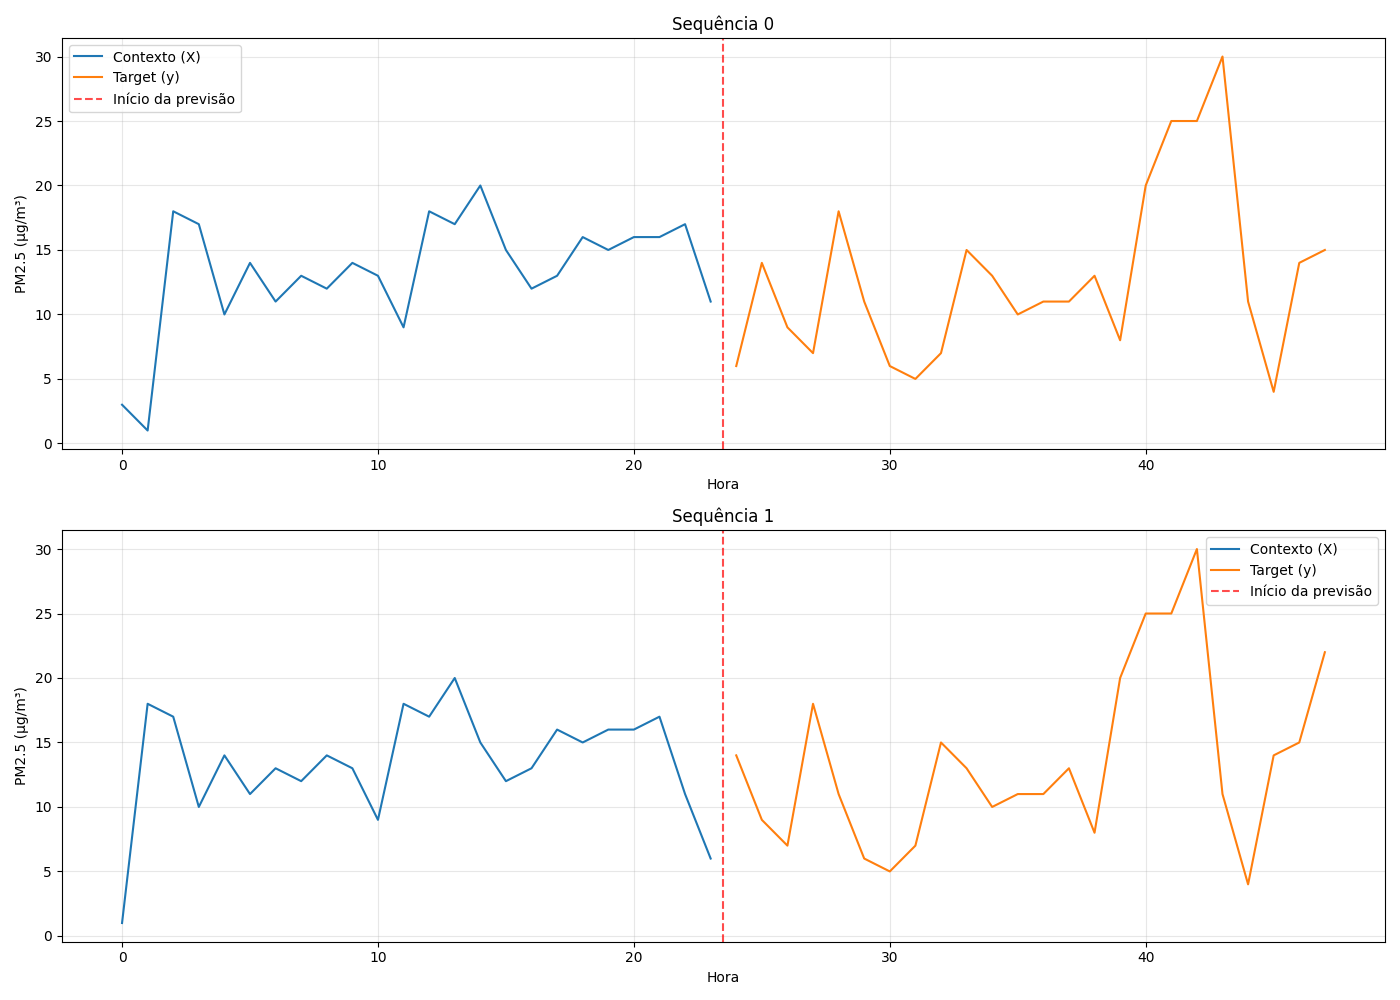

In [24]:
# verificar primeiras 2 sequências do treino
plot_sequencias(X_train, y_train, scaler, target_idx, n_features=X_train.shape[2])

### 6. Modelo

In [25]:
n_features = X_train.shape[2]

def init_model():

    model = Sequential()
    model.add(Input(shape=(WINDOW, n_features)))

    model.add(LSTM(64, activation='tanh', return_sequences=True))
    #model.add(Dropout(0.1))

    model.add(LSTM(32, activation='tanh', return_sequences=False))
    #model.add(Dropout(0.1))

    model.add(Dense(HORIZON, activation='linear'))

    model.compile(
        loss="mae",
        optimizer=Adam(learning_rate=0.001),
        metrics=["mae"]
    )

    return model

In [26]:
model = init_model()

model.summary()

E0000 00:00:1782435447.071146   12848 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,408 (126.59 KB)

 Trainable params: 32,408 (126.59 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 72s 111ms/step - loss: 0.0662 - mae: 0.0662 - val_loss: 0.0622 - val_mae: 0.0622
Epoch 2/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 0.0605 - mae: 0.0605 - val_loss: 0.0597 - val_mae: 0.0597
Epoch 3/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 0.0591 - mae: 0.0591 - val_loss: 0.0589 - val_mae: 0.0589
Epoch 4/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 0.0582 - mae: 0.0582 - val_loss: 0.0584 - val_mae: 0.0584
Epoch 5/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0573 - mae: 0.0573 - val_loss: 0.0588 - val_mae: 0.0588
Epoch 6/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 0.0566 - mae: 0.0566 - val_loss: 0.0581 - val_mae: 0.0581
Epoch 7/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - loss: 0.0560 - mae: 0.0560 - val_loss: 0.0578 - val_mae: 0.0578
Epoch 8/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0555 - mae: 0.0555 - val_loss: 0.0581 - val_mae: 0.0581
Epoch 9/100
502/502 ━━━━━━━━━━━

In [28]:
def plot_history(history):

    fig, ax = plt.subplots(1,2, figsize=(20,7))
    # --- LOSS: MSE ---
    ax[0].plot(history.history['loss'])
    ax[0].plot(history.history['val_loss'])
    ax[0].set_title('MSE')
    ax[0].set_ylabel('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend(['Train', 'Validation'], loc='best')
    ax[0].grid(axis="x",linewidth=0.5)
    ax[0].grid(axis="y",linewidth=0.5)

    # --- METRICS:MAE ---

    ax[1].plot(history.history['mae'])
    ax[1].plot(history.history['val_mae'])
    ax[1].set_title('MAE')
    ax[1].set_ylabel('MAE')
    ax[1].set_xlabel('Epoch')
    ax[1].legend(['Train', 'Validation'], loc='best')
    ax[1].grid(axis="x",linewidth=0.5)
    ax[1].grid(axis="y",linewidth=0.5)

    return ax

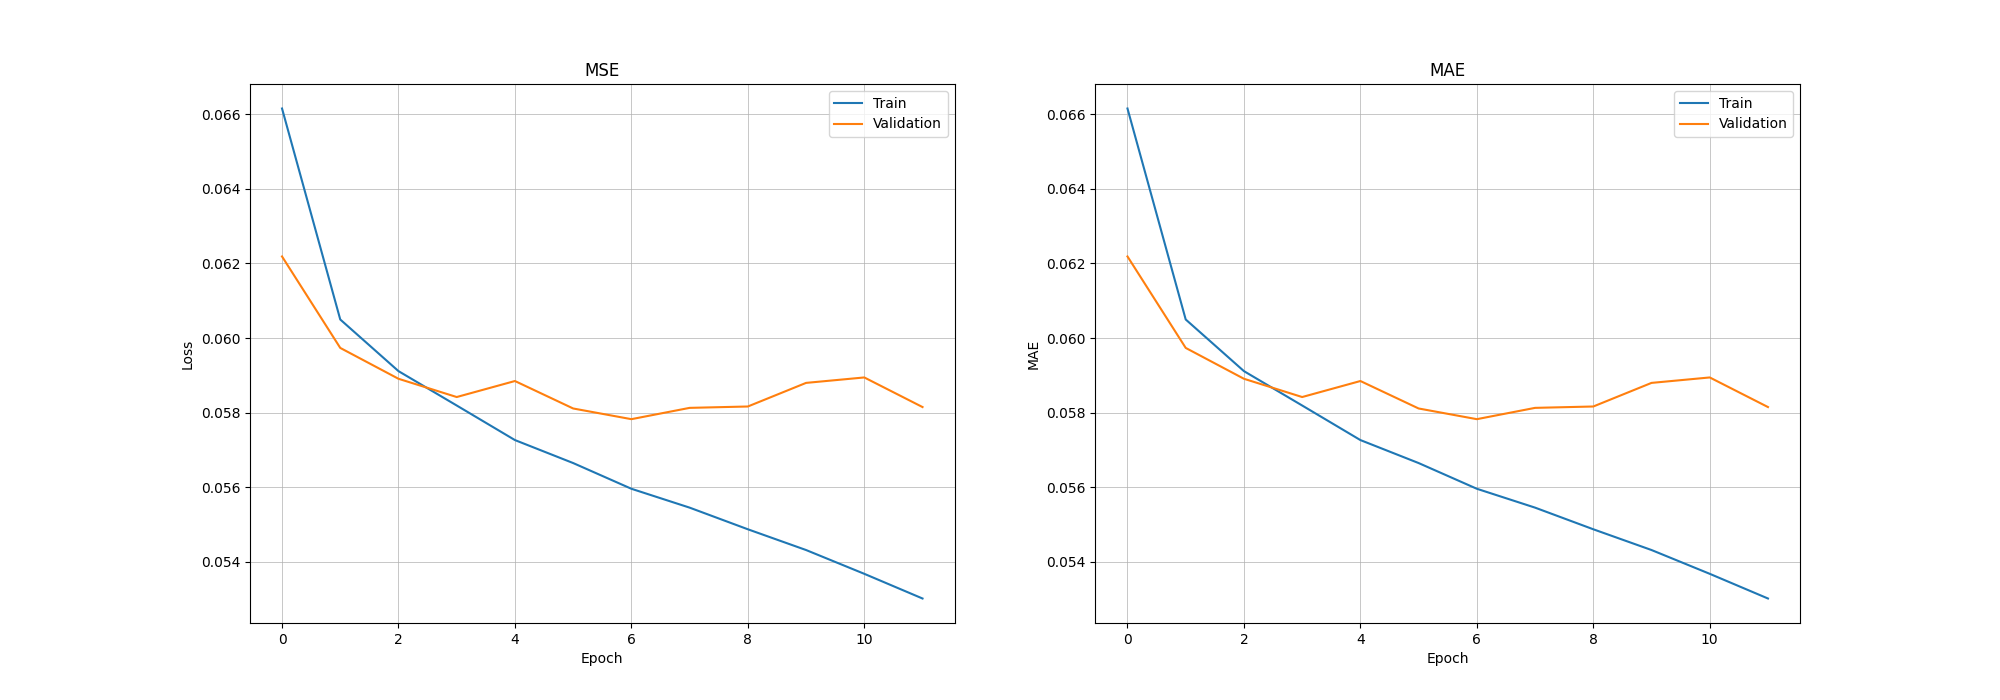

In [29]:
plot_history(history);

In [30]:
#inverter nomalização
y_pred = model.predict(X_val)

n_cols_scaler = scaler.n_features_in_

pred_inv_list = []
true_inv_list = []

for h in range(HORIZON):

    pred_fake = np.zeros((len(y_pred), n_cols_scaler))
    true_fake = np.zeros((len(y_val), n_cols_scaler))

    pred_fake[:, target_idx] = y_pred[:, h]
    true_fake[:, target_idx] = y_val[:, h]

    pred_inv_h = scaler.inverse_transform(pred_fake)[:, target_idx]
    true_inv_h = scaler.inverse_transform(true_fake)[:, target_idx]

    pred_inv_list.append(pred_inv_h)
    true_inv_list.append(true_inv_h)

pred_inv = np.array(pred_inv_list).T
true_inv = np.array(true_inv_list).T

274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [31]:
mae = mean_absolute_error(true_inv.flatten(), pred_inv.flatten())
rmse = np.sqrt(mean_squared_error(true_inv.flatten(), pred_inv.flatten()))
r2 = r2_score(true_inv.flatten(), pred_inv.flatten())

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

MAE: 6.881
RMSE: 9.866
R²: 0.394


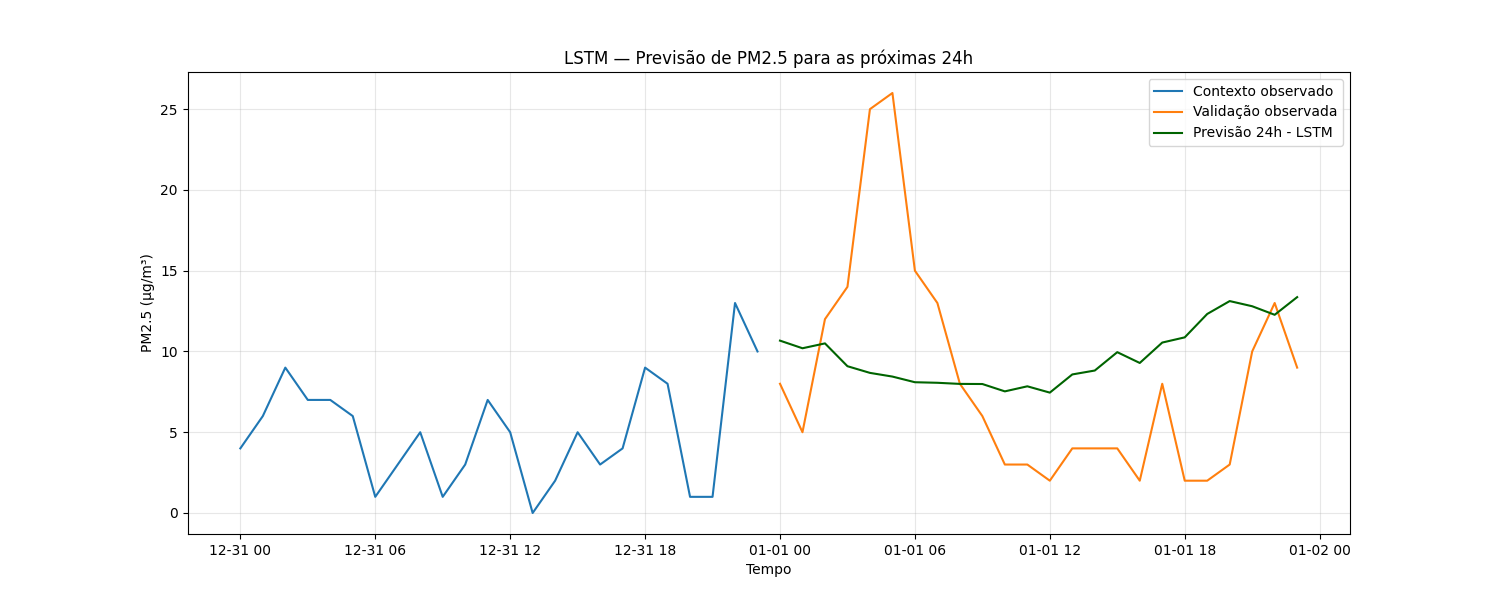

In [32]:
janela = 0

pred_24h = pred_inv[janela]
obs_24h = true_inv[janela]

context_index = val_x_idx[janela]
forecast_index = val_y_idx[janela]

plt.figure(figsize=(15, 6))

plt.plot(
    context_index,
    val_context.loc[context_index, TARGET],
    label="Contexto observado"
)

plt.plot(
    forecast_index,
    obs_24h,
    label="Validação observada"
)

plt.plot(
    forecast_index,
    pred_24h,
    label="Previsão 24h - LSTM",
    color="darkgreen"
)

plt.title("LSTM — Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
print(f"scaler n_features  : {scaler.n_features_in_}")
print(f"X_train n_features : {X_train.shape[2]}")
print(f"target_idx         : {target_idx}")

# verificar se a inversão está correta
# pega primeira sequência e inverte
dummy = np.zeros((1, scaler.n_features_in_))
dummy[0, target_idx] = X_train[0, -1, target_idx]  # último valor do contexto
valor_inv = scaler.inverse_transform(dummy)[0, target_idx]
valor_orig = train_feat["MP2.5"].dropna().iloc[WINDOW - 1]

print(f"Valor invertido    : {valor_inv:.3f}")
print(f"Valor original     : {valor_orig:.3f}")

scaler n_features  : 10
X_train n_features : 10
target_idx         : 0
Valor invertido    : 11.000
Valor original     : 11.000


In [ ]:
print(f"y_train min: {y_train.min():.4f}")
print(f"y_train max: {y_train.max():.4f}")
print(f"y_train mean: {y_train.mean():.4f}")

y_train min: 0.0000
y_train max: 1.0000
y_train mean: 0.1584


In [35]:
print(f"PM2.5 max treino : {train_feat['MP2.5'].max():.1f}")
print(f"PM2.5 max val    : {val_feat['MP2.5'].max():.1f}")
print(f"PM2.5 max teste  : {test_feat['MP2.5'].max():.1f}")


PM2.5 max treino : 119.0
PM2.5 max val    : 103.0
PM2.5 max teste  : 105.0


In [36]:
print(f"X_train shape: {X_train.shape}")


X_train shape: (16057, 24, 10)


**Fazendo previsão a cada 1 hora em 24h**

In [37]:
# ============================================================
# Teste diagnóstico LSTM — previsão 1h à frente
# ============================================================

WINDOW = 24
HORIZON = 1

# recriar sequências
X_train_1h, y_train_1h, train_x_idx_1h, train_y_idx_1h = create_sequences(
    train_scaled,
    train_feat,
    WINDOW,
    HORIZON,
    target_idx
)

val_context = pd.concat([
    train_feat.iloc[-WINDOW:],
    val_feat
])

val_context_scaled = scaler.transform(val_context)

X_val_1h, y_val_1h, val_x_idx_1h, val_y_idx_1h = create_sequences(
    val_context_scaled,
    val_context,
    WINDOW,
    HORIZON,
    target_idx
)

print("X_train:", X_train_1h.shape)
print("y_train:", y_train_1h.shape)
print("X_val:", X_val_1h.shape)
print("y_val:", y_val_1h.shape)

X_train: (16080, 24, 10)
y_train: (16080, 1)
X_val: (8760, 24, 10)
y_val: (8760, 1)


In [38]:
n_features = X_train_1h.shape[2]

model_1h = Sequential([
    Input(shape=(WINDOW, n_features)),

    LSTM(
        64,
        activation="tanh",
        return_sequences=False
    ),

    Dense(1, activation="linear")
])

model_1h.compile(
    loss="mae",
    optimizer=Adam(learning_rate=0.001),
    metrics=["mae"]
)

model_1h.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history_1h = model_1h.fit(
    X_train_1h,
    y_train_1h,
    validation_data=(X_val_1h, y_val_1h),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.0482 - mae: 0.0482 - val_loss: 0.0443 - val_mae: 0.0443
Epoch 2/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0414 - mae: 0.0414 - val_loss: 0.0410 - val_mae: 0.0410
Epoch 3/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0395 - mae: 0.0395 - val_loss: 0.0394 - val_mae: 0.0394
Epoch 4/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0392 - mae: 0.0392 - val_loss: 0.0396 - val_mae: 0.0396
Epoch 5/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0391 - mae: 0.0391 - val_loss: 0.0395 - val_mae: 0.0395
Epoch 6/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.0388 - mae: 0.0388 - val_loss: 0.0393 - val_mae: 0.0393
Epoch 7/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.0385 - mae: 0.0385 - val_loss: 0.0396 - val_mae: 0.0396
Epoch 8/100
503/503 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0386 - mae: 0.0386 - val_loss: 0.0394 - val_mae: 0.0394
Epoch 9/100
503/503 ━━━━━━━━━━━━━━━━

In [ ]:
def recursive_forecast_24h(
    model,
    X_start,
    future_features_scaled,
    target_idx,
    horizon=24
):
    """
    Previsão recursiva de 24h com modelo LSTM treinado para HORIZON=1.
    """

    current_window = X_start.copy()

    predictions = []

    for h in range(horizon):

        # (1, WINDOW, n_features)
        X_input = current_window.reshape(1, current_window.shape[0], current_window.shape[1])


        yhat = model.predict(X_input, verbose=0)[0, 0]

        predictions.append(yhat)


        next_row = future_features_scaled[h].copy()


        next_row[target_idx] = yhat

        current_window = np.vstack([
            current_window[1:],
            next_row
        ])

    return np.array(predictions)

In [41]:
janela = 0

X_start = X_val_1h[janela]

# próximas 24h de features conhecidas
future_features_scaled = val_context_scaled[
    WINDOW + janela : WINDOW + janela + 24
]

pred_24h_scaled = recursive_forecast_24h(
    model=model_1h,
    X_start=X_start,
    future_features_scaled=future_features_scaled,
    target_idx=target_idx,
    horizon=24
)

In [42]:
n_cols_scaler = scaler.n_features_in_

pred_fake = np.zeros((24, n_cols_scaler))
pred_fake[:, target_idx] = pred_24h_scaled

pred_24h_inv = scaler.inverse_transform(pred_fake)[:, target_idx]

In [43]:
obs_24h_inv = val_context[
    TARGET
].iloc[WINDOW + janela : WINDOW + janela + 24].values

In [44]:
index_24h = val_context.index[
    WINDOW + janela : WINDOW + janela + 24
]

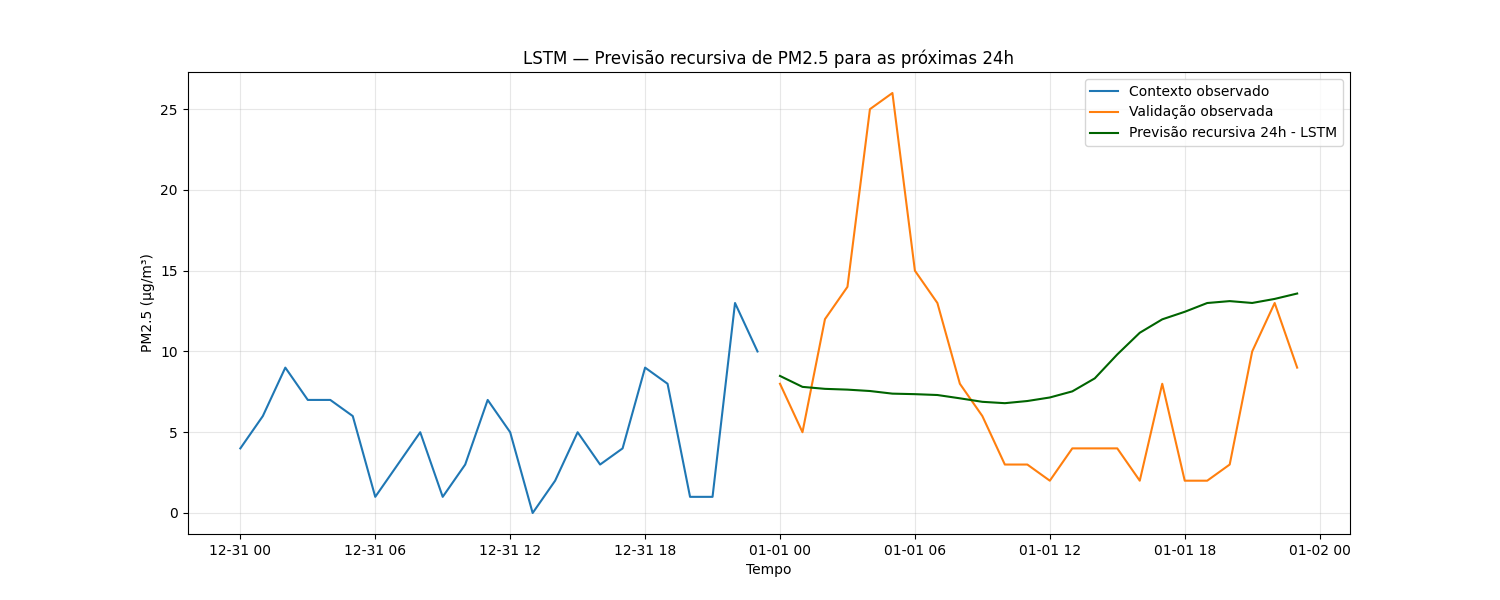

In [45]:
plt.figure(figsize=(15, 6))

plt.plot(
    val_context[TARGET].iloc[janela : WINDOW + janela],
    label="Contexto observado"
)

plt.plot(
    index_24h,
    obs_24h_inv,
    label="Validação observada"
)

plt.plot(
    index_24h,
    pred_24h_inv,
    label="Previsão recursiva 24h - LSTM",
    color="darkgreen"
)

plt.title("LSTM — Previsão recursiva de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()